In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, ShallowDataLoaderManager, GraphDataLoaderManager
from src.models import PersistenceModel, NodeRFModel, ClimateologyModel, NodeLSTMModel

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2010-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    include_gisd        = True,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',    
    )    

data_orchestrator = DataOrchestrator(config).build()
shallowdata       = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
deepdata          = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23029856/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


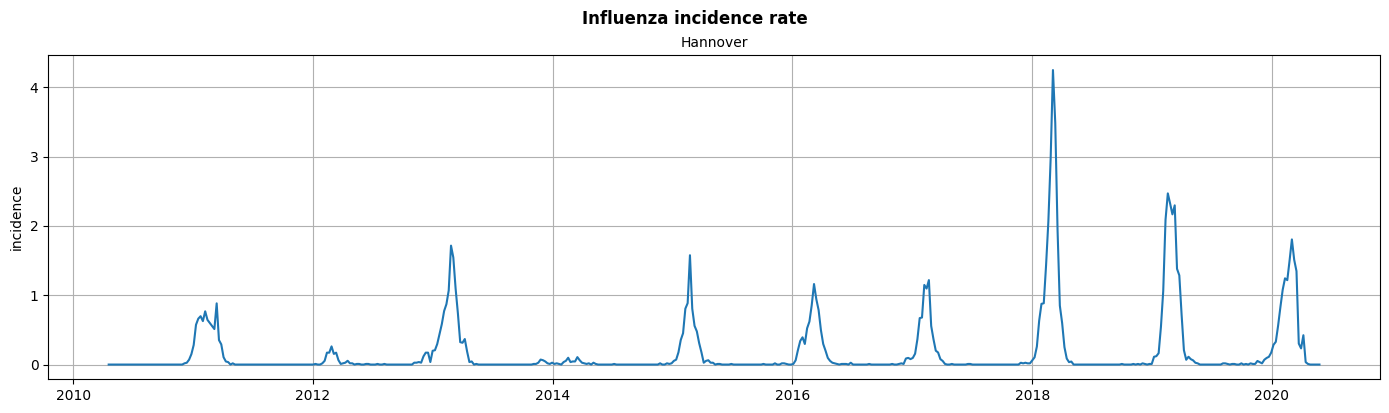

In [2]:
dataloader_hannover = data_orchestrator.preview(26, 'processed')
dataloader_hannover.labels.change_suptitle('Influenza incidence rate',fontweight='bold', fontsize=12).labels.change_title('Hannover').labels.set_suptitle_y(1.02).show()
# data_orchestrator.preview(15, 'processed')
# data_orchestrator.preview(223, 'processed')

In [2]:
v = -1
persistence = PersistenceModel(shallowdata, verbose = v)
persistence.forecast('test')

climateology = ClimateologyModel(shallowdata, verbose = v)
climateology.forecast('test')

forest = NodeRFModel(shallowdata, verbose = v)
forest.set_global_hparams()
forest.set_model_hparams(n_estimators=1)
forest.train()
forest.forecast('test')

forest2 = NodeRFModel(shallowdata, verbose = v, name = 'rf2')
forest2.set_global_hparams()
forest2.set_model_hparams(n_estimators=10)
forest2.train()
forest2.forecast('test')

f1=climateology.show_forecasts(26)
f2=persistence.show_forecasts(26)
f3=forest.show_forecasts(26)

In [4]:
# lstm = NodeLSTMModel(deepdata, name = 'lstm')
# lstm.set_model_hparams()
# lstm.set_global_hparams()
# lstm.train()
# lstm.forecast('test')
# lstm.show_forecasts(26)

In [5]:
from src.evaluation import Evaluator
evaluation = Evaluator([persistence,climateology, forest, forest2])
evaluation.add_evaluation(horizon = 0)
fx = evaluation.plotter.plot_timeseries(nodes = [26])
fy = evaluation.plotter.plot_metric('ccc', 0, plot_type='box')


computing metrics:   0%|                                                                                                                                                                | 0/6 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:04<00:00,  1.46it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


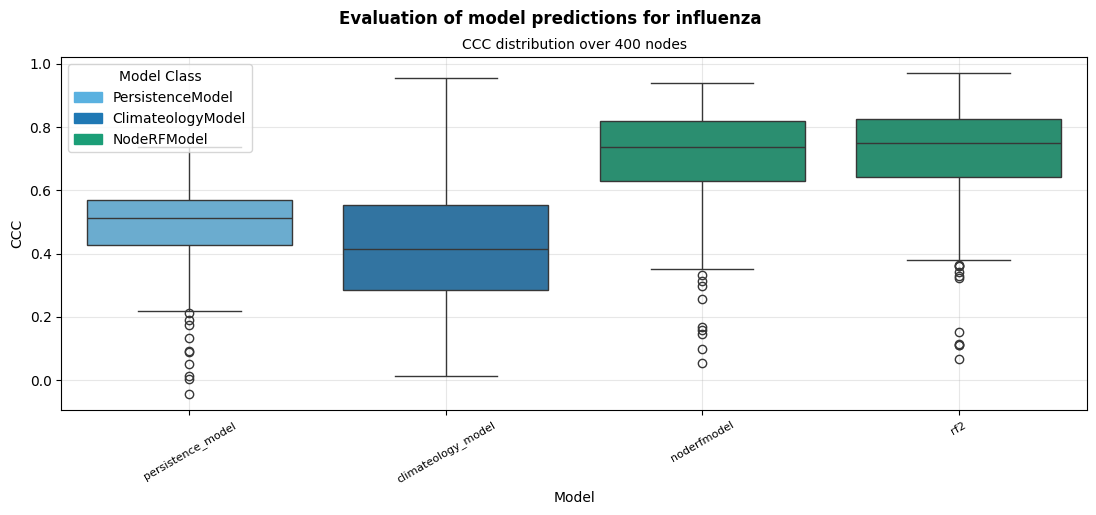

In [10]:
fy.labels.change_suptitle('Evaluation of model predictions for influenza','bold',12).labels.change_title('CCC distribution over 400 nodes').change_figsize(11,5).legend.move('upper left').labels.set_suptitle_y(1.02).show()

In [7]:
# evaluation.plotter.plot_metric('spearman_corr', horizon='horizon_0')
# evaluation.plotter.plot_metric('pearson_corr', horizon='horizon_0')
# evaluation.plotter.plot_metric('node_smape', horizon='horizon_0')
# evaluation.plotter.plot_metric('mse', horizon='horizon_0')
# evaluation.plotter.plot_metric('rmse', horizon='horizon_0')
# evaluation.plotter.plot_metric('ccc', horizon='horizon_0')

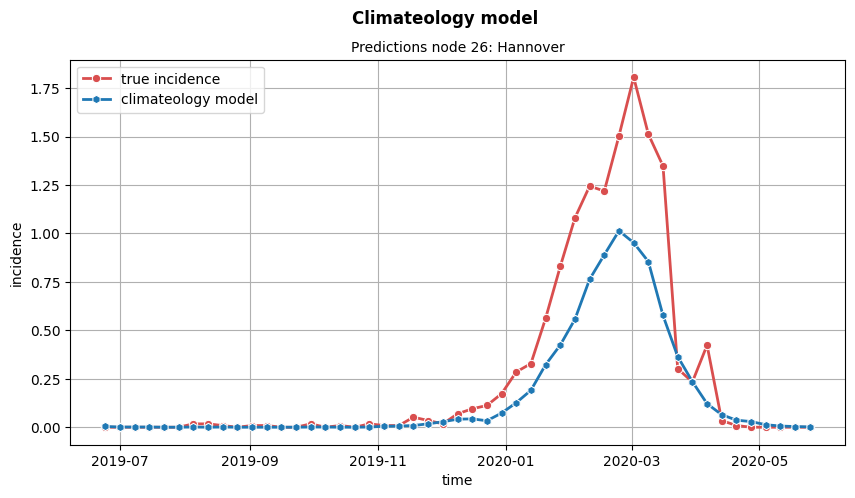

In [3]:
f1.labels.change_suptitle('Climateology model','bold',12).labels.change_title('Predictions node 26: Hannover').labels.change_xlab('time').labels.change_ylab('incidence').legend.set_labels(['true incidence','climateology model']).change_figsize(10,5).legend.move('upper left').show()